In [33]:
import pandas as pd
import matplotlib.pyplot as plt


red = pd.read_csv('../data/raw/winequality-red.csv', sep=';')
white = pd.read_csv('../data/raw/winequality-white.csv', sep=';')

In [15]:
print(red.shape, white.shape)

(1599, 12) (4898, 12)


In [19]:
def show_stats(df):
    df.head()
    df.info()
    print(df.dtypes)
    print(df.columns)
    print(df.duplicated().sum())

show_stats(red)
show_stats(white)

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides

In [ ]:
red.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [23]:
white.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000
mean,6.854788,0.278241,0.334192,6.391415,0.045772,35.308085,138.360657,0.994027,3.188267,0.489847,10.514267,5.877909
std,0.843868,0.100795,0.121020,5.072058,0.021848,17.007137,42.498065,0.002991,0.151001,0.114126,1.230621,0.885639
min,3.800000,0.080000,0.000000,0.600000,0.009000,2.000000,9.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.300000,0.210000,0.270000,1.700000,0.036000,23.000000,108.000000,0.991723,3.090000,0.410000,9.500000,5.000000
50%,6.800000,0.260000,0.320000,5.200000,0.043000,34.000000,134.000000,0.993740,3.180000,0.470000,10.400000,6.000000
75%,7.300000,0.320000,0.390000,9.900000,0.050000,46.000000,167.000000,0.996100,3.280000,0.550000,11.400000,6.000000
max,14.200000,1.100000,1.660000,65.800000,0.346000,289.000000,440.000000,1.038980,3.820000,1.080000,14.200000,9.000000


In [24]:
red["wine_type"] = "red"
white["wine_type"] = "white"

In [27]:
combined = pd.concat([red, white], ignore_index=True)
combined.shape

(6497, 13)

In [28]:
show_stats(combined)

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  wine_type             6497 non-null   str    
dtypes: float64(11), int64(1), str(1)
memory usage: 660.0 KB
fixed acidity           float64
volatile acidity        float64
citric acid   

In [29]:
combined.groupby("wine_type")["quality"].describe()

,count,mean,std,min,25%,50%,75%,max
wine_type,,,,,,,,
red,1599.0,5.636023,0.807569,3.0,5.0,6.0,6.0,8.0
white,4898.0,5.877909,0.885639,3.0,5.0,6.0,6.0,9.0


In [37]:
combined["quality"].value_counts().sort_index()

quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64

In [ ]:
combined.sort_values('quality', ascending=False).head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
3204,7.1,0.260,0.49,2.20,0.032,31.0,113.0,0.99030,3.37,0.42,12.9,9,white
2475,6.9,0.360,0.34,4.20,0.018,57.0,119.0,0.98980,3.28,0.36,12.7,9,white
2419,6.6,0.360,0.29,1.60,0.021,24.0,85.0,0.98965,3.41,0.61,12.4,9,white
2426,7.4,0.240,0.36,2.00,0.031,27.0,139.0,0.99055,3.28,0.48,12.5,9,white
2373,9.1,0.270,0.45,10.60,0.035,28.0,124.0,0.99700,3.20,0.46,10.4,9,white
3063,8.0,0.440,0.49,9.10,0.031,46.0,151.0,0.99260,3.16,0.27,12.7,8,white
3314,6.5,0.180,0.34,1.60,0.040,43.0,148.0,0.99120,3.32,0.59,11.5,8,white
3005,8.2,0.220,0.36,6.80,0.034,12.0,90.0,0.99440,3.01,0.38,10.5,8,white
4121,7.3,0.170,0.24,8.10,0.121,32.0,162.0,0.99508,3.17,0.38,10.4,8,white
4124,7.3,0.170,0.24,8.10,0.121,32.0,162.0,0.99508,3.17,0.38,10.4,8,white


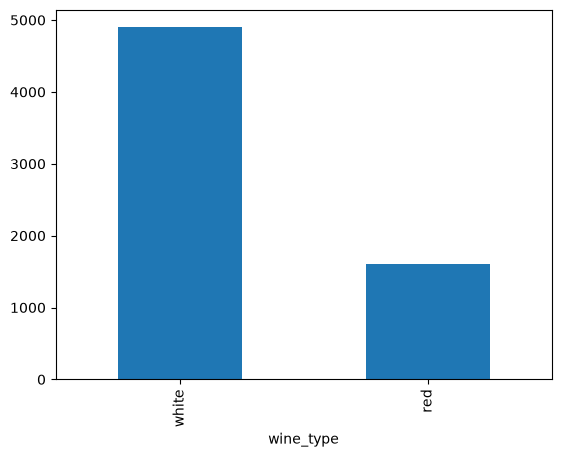

In [44]:
combined["wine_type"].value_counts().plot(kind="bar")
plt.show()

In [46]:
pd.crosstab(
    combined["wine_type"],
    combined["quality"]
)

quality,3,4,5,6,7,8,9
wine_type,,,,,,,
red,10,53,681,638,199,18,0
white,20,163,1457,2198,880,175,5


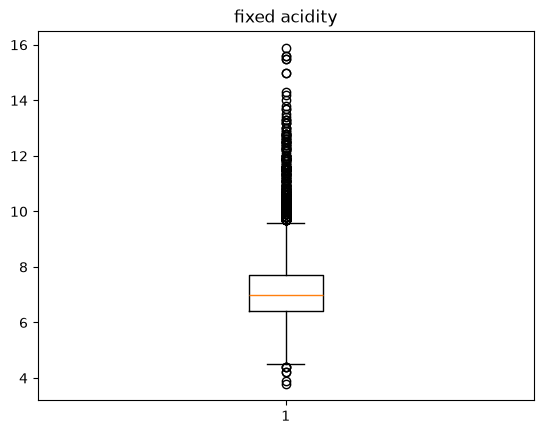

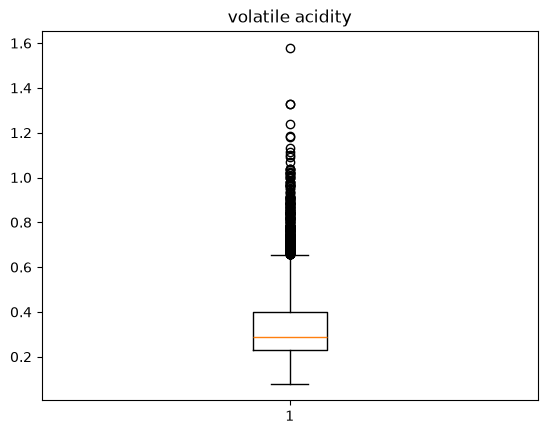

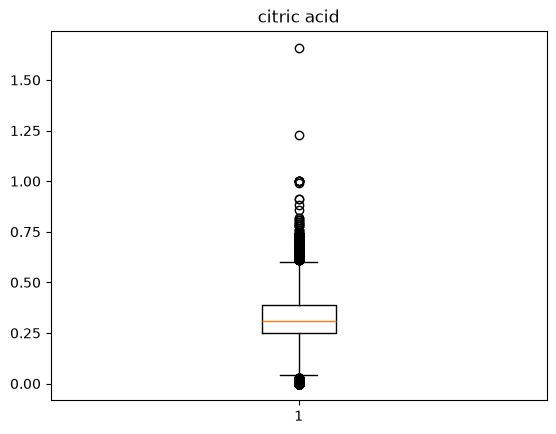

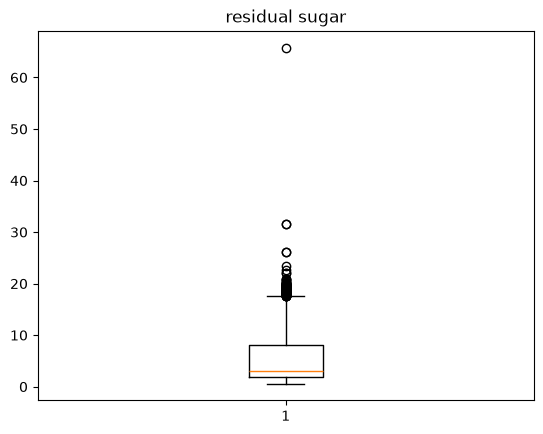

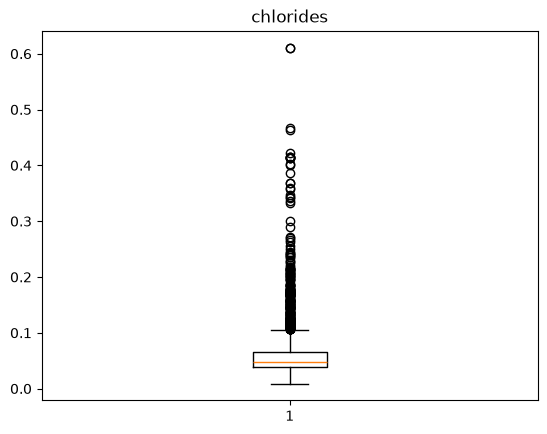

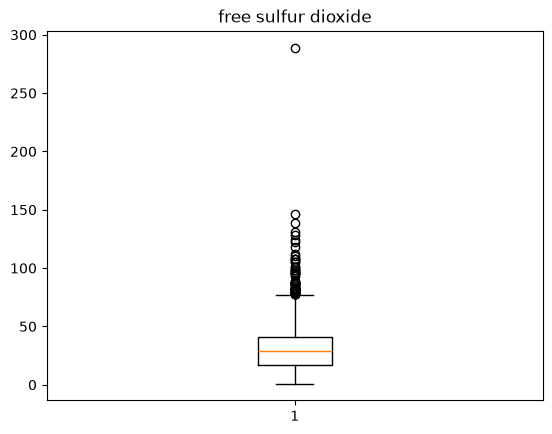

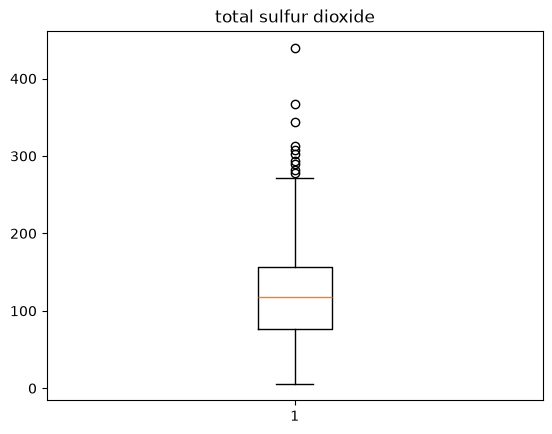

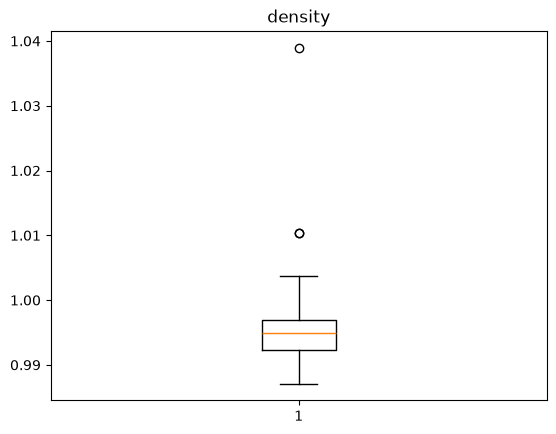

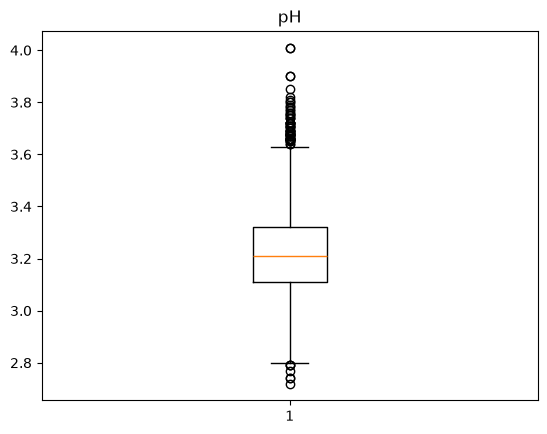

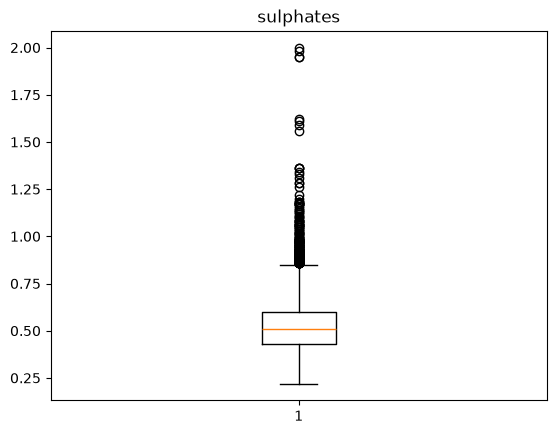

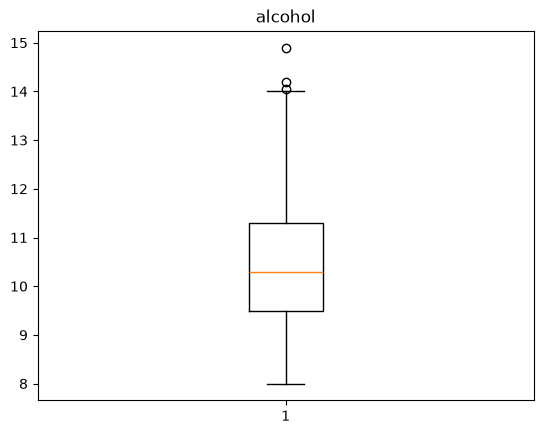

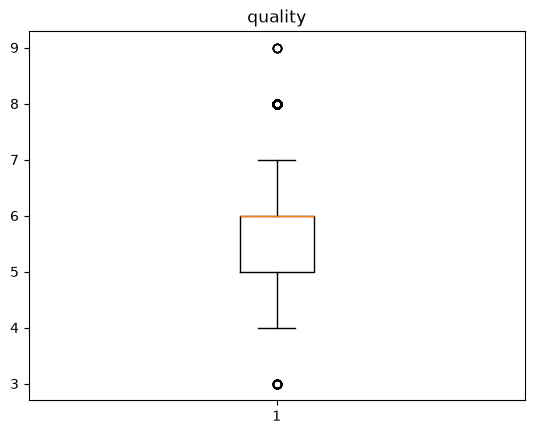

In [51]:
for category in combined.select_dtypes(include="number").columns:
    plt.boxplot(combined[category])
    plt.title(category)
    plt.show()

In [54]:
def show_outliers(df, category):
    Q1 = df[category].quantile(.25)
    Q3 = df[category].quantile(.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers_count = ( (df[category] < lower_bound) | (df[category] > upper_bound) ).sum()
    print(f"{category}\n Q1: {Q1}, Q3: {Q3}, IQR: {IQR}, normal data in [{lower_bound}, {upper_bound}], outliers count: {outliers_count}\n")

for category in combined.select_dtypes(include="number").columns:
    show_outliers(combined, category)

fixed acidity
 Q1: 6.4, Q3: 7.7, IQR: 1.2999999999999998, normal data in [4.450000000000001, 9.65], outliers count: 357

volatile acidity
 Q1: 0.23, Q3: 0.4, IQR: 0.17, normal data in [-0.024999999999999994, 0.655], outliers count: 377

citric acid
 Q1: 0.25, Q3: 0.39, IQR: 0.14, normal data in [0.03999999999999998, 0.6000000000000001], outliers count: 509

residual sugar
 Q1: 1.8, Q3: 8.1, IQR: 6.3, normal data in [-7.6499999999999995, 17.549999999999997], outliers count: 118

chlorides
 Q1: 0.038, Q3: 0.065, IQR: 0.027000000000000003, normal data in [-0.002500000000000009, 0.10550000000000001], outliers count: 286

free sulfur dioxide
 Q1: 17.0, Q3: 41.0, IQR: 24.0, normal data in [-19.0, 77.0], outliers count: 62

total sulfur dioxide
 Q1: 77.0, Q3: 156.0, IQR: 79.0, normal data in [-41.5, 274.5], outliers count: 10

density
 Q1: 0.99234, Q3: 0.99699, IQR: 0.004650000000000043, normal data in [0.9853649999999999, 1.003965], outliers count: 3

pH
 Q1: 3.11, Q3: 3.32, IQR: 0.209999999

In [55]:
combined[combined.duplicated(keep=False)].sort_values(
    list(combined.columns)
)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
6270,4.9,0.335,0.14,1.3,0.036,69.0,168.0,0.99212,3.47,0.46,10.466667,5,white
6271,4.9,0.335,0.14,1.3,0.036,69.0,168.0,0.99212,3.47,0.46,10.466667,5,white
5540,4.9,0.345,0.34,1.0,0.068,32.0,143.0,0.99138,3.24,0.40,10.100000,5,white
5549,4.9,0.345,0.34,1.0,0.068,32.0,143.0,0.99138,3.24,0.40,10.100000,5,white
4589,5.0,0.270,0.32,4.5,0.032,58.0,178.0,0.98956,3.45,0.31,12.600000,7,white
...,...,...,...,...,...,...,...,...,...,...,...,...,...
391,13.7,0.415,0.68,2.9,0.085,17.0,43.0,1.00140,3.06,0.80,10.000000,6,red
243,15.0,0.210,0.44,2.2,0.075,10.0,24.0,1.00005,3.07,0.84,9.200000,7,red
244,15.0,0.210,0.44,2.2,0.075,10.0,24.0,1.00005,3.07,0.84,9.200000,7,red
554,15.5,0.645,0.49,4.2,0.095,10.0,23.0,1.00315,2.92,0.74,11.100000,5,red


In [58]:
(combined.groupby(
    list(combined.columns.drop("quality"))
)["quality"].nunique() != 1 ).sum()

np.int64(0)

In [59]:
combined["quality"].value_counts().sort_index()

quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64

In [60]:
combined["quality"].value_counts(normalize=True).sort_index()

quality
3    0.004618
4    0.033246
5    0.329075
6    0.436509
7    0.166077
8    0.029706
9    0.000770
Name: proportion, dtype: float64

In [66]:
mask = pd.Series(False, index=combined.index)
for category in combined.select_dtypes(include='number').columns.drop('quality'):
    Q1 = combined[category].quantile(.25)
    Q3 = combined[category].quantile(.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = (combined[category] < lower_bound) | (combined[category] > upper_bound)
    mask = mask | outliers
mask.sum()

np.int64(1473)